# Homework №4

## Описание датасета (ToyotaCorolla)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("ToyotaCorolla.csv")
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [5]:
df.shape

(1436, 39)

Размерность датасета 1436 x 39

In [6]:
df.dtypes

Id                   int64
Model                  str
Price                int64
Age_08_04            int64
Mfg_Month            int64
Mfg_Year             int64
KM                   int64
Fuel_Type              str
HP                   int64
Met_Color            int64
Color                  str
Automatic            int64
CC                   int64
Doors                int64
Cylinders            int64
Gears                int64
Quarterly_Tax        int64
Weight               int64
Mfr_Guarantee        int64
BOVAG_Guarantee      int64
Guarantee_Period     int64
ABS                  int64
Airbag_1             int64
Airbag_2             int64
Airco                int64
Automatic_airco      int64
Boardcomputer        int64
CD_Player            int64
Central_Lock         int64
Powered_Windows      int64
Power_Steering       int64
Radio                int64
Mistlamps            int64
Sport_Model          int64
Backseat_Divider     int64
Metallic_Rim         int64
Radio_cassette       int64
P

Датасет содержит преимущественно числовые признаки

In [7]:
df.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

Пропуски отсутствуют

In [8]:
df.duplicated().sum()

np.int64(0)

Дубликатов также нет

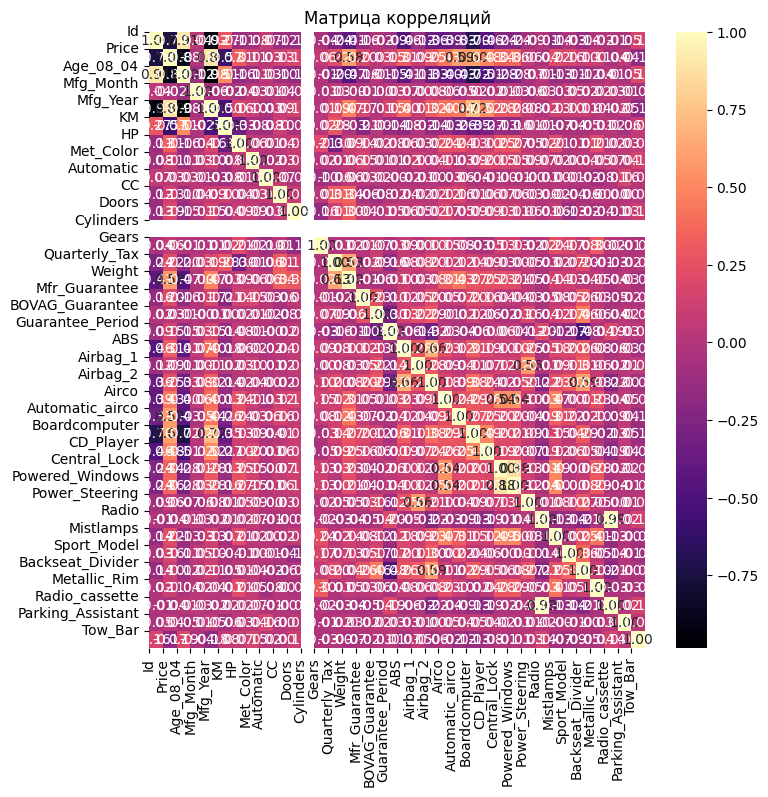

In [9]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций")
plt.show()

Датасет подготовлен для следующего этапа - работы с признаковым пространством

## Feature Engineering

Закодируем признаки Fuel Type и Color, чтобы сделать их числовыми

In [10]:
df = pd.get_dummies(df, columns=['Color', 'Fuel_Type'])
df.head()


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,...,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,90,1,0,...,False,False,False,False,False,False,False,False,True,False
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,90,1,0,...,False,False,False,True,False,False,False,False,True,False
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,90,1,0,...,False,False,False,False,False,False,False,False,True,False
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,90,0,0,...,False,False,False,False,False,False,False,False,True,False
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,90,0,0,...,False,False,False,False,False,False,False,False,True,False


Удалим признаки год и месяц производства, так как они неинформативны, ведь уже есть возраст автомобиля. Удалим признак Model, так как он содержит повторяющуся информацию

In [11]:
df = df.drop(['Mfg_Month', 'Mfg_Year', 'Model', 'Id'], axis=1)
df.head()

,Price,Age_08_04,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,...,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,1,0,2000,3,4,5,...,False,False,False,False,False,False,False,False,True,False
1,13750,23,72937,90,1,0,2000,3,4,5,...,False,False,False,True,False,False,False,False,True,False
2,13950,24,41711,90,1,0,2000,3,4,5,...,False,False,False,False,False,False,False,False,True,False
3,14950,26,48000,90,0,0,2000,3,4,5,...,False,False,False,False,False,False,False,False,True,False
4,13750,30,38500,90,0,0,2000,3,4,5,...,False,False,False,False,False,False,False,False,True,False


Добавим признак соотношения мощности автомобиля и веса, так как они взаимозависимы

In [12]:
df['Power_to_Weight'] = df['HP'] / df['Weight']
df = df.drop(['HP', 'Weight'], axis=1)
df.head()

,Price,Age_08_04,KM,Met_Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,...,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Power_to_Weight
0,13500,23,46986,1,0,2000,3,4,5,210,...,False,False,False,False,False,False,False,True,False,0.077253
1,13750,23,72937,1,0,2000,3,4,5,210,...,False,False,True,False,False,False,False,True,False,0.077253
2,13950,24,41711,1,0,2000,3,4,5,210,...,False,False,False,False,False,False,False,True,False,0.077253
3,14950,26,48000,0,0,2000,3,4,5,210,...,False,False,False,False,False,False,False,True,False,0.077253
4,13750,30,38500,0,0,2000,3,4,5,210,...,False,False,False,False,False,False,False,True,False,0.076923


Разобьем выборку

In [13]:
X = df.drop('Price', axis=1)
y = df['Price']

Также нужно масштабировать признаки, так как они довольно сильно различаются

In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
print(X)

[[-1.77196633 -0.57469494  0.69421909 ...  2.87480715 -2.71087388
  -1.28126885]
 [-1.77196633  0.11745379  0.69421909 ...  2.87480715 -2.71087388
  -1.28126885]
 [-1.71818412 -0.71538641  0.69421909 ...  2.87480715 -2.71087388
  -1.28126885]
 ...
 [ 0.80957948 -1.37403589 -1.44046745 ... -0.34784942  0.36888474
  -0.73486178]
 [ 0.75579727 -1.37670303  0.69421909 ... -0.34784942  0.36888474
  -0.73486178]
 [ 1.0784905  -1.82784925 -1.44046745 ... -0.34784942  0.36888474
   0.28943174]]


## Разделение выборки

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Выборка разделена библиотечным методом в соотношении 80/20 случайным образом (но зафиксированным). Это нужно для того, чтобы во время теста модель получала неизвестные данные

## Обучение линейной модели

In [16]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_test_predict = lin_model.predict(X_test)
print(np.sqrt(mean_squared_error(y_test, y_test_predict)))
print(r2_score(y_test, y_test_predict))


1171.990964849676
0.8970557926248199


## Обучение модели Ridge (L2-регуляризатор)

In [17]:
l2_model = Ridge()
l2_model.fit(X_train, y_train)
y_test_predict_2 = l2_model.predict(X_test)
print(np.sqrt(mean_squared_error(y_test, y_test_predict_2)))
print(r2_score(y_test, y_test_predict_2))


1171.4714852314587
0.8971470314949793


## Обучение модели Lasso (L1-регуляризатор)

In [18]:
l1_model = Lasso()
l1_model.fit(X_train, y_train)
y_test_predict_1 = l1_model.predict(X_test)
print(np.sqrt(mean_squared_error(y_test, y_test_predict_1)))
print(r2_score(y_test, y_test_predict_1))


1171.1679917331555
0.8972003168956895


## Сравнение моделей

Для сравнения моделей были использованы метрики были использованы RMSE и R2. Выбор таков, так как первая метрика отвечает за абсолютную точность и показывает численную ошибку, а вторая метрика - за относительную и показывае процент правильности. Метрики считались на тестовой выборке, так как там эксперимент будет наиболее чистым. 

Результаты получились очень хорошими. Тончность составляет около 90%.

Все модели справились практические одинаково. Следовательно, регуляризация не нужна. Это говорит о том, что признаковое пространство было обработано должным образом и скоррелированных признаков нет

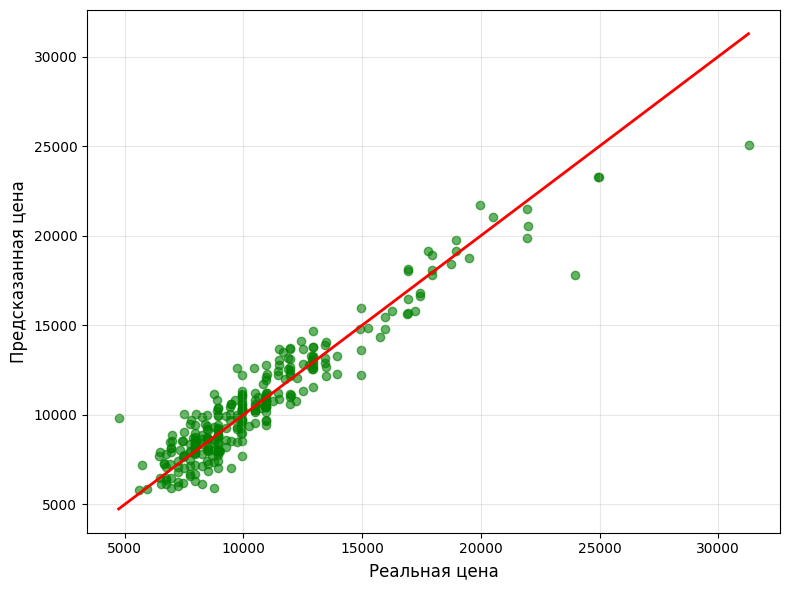

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_predict, alpha=0.6, color='green')
min_val = min(y_test.min(), y_test_predict.min())
max_val = max(y_test.max(), y_test_predict.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r', linewidth=2)
plt.xlabel('Реальная цена', fontsize=12)
plt.ylabel('Предсказанная цена', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
r2_train = r2_score(y_train, lin_model.predict(X_train))
r2_test = r2_score(y_test, y_test_predict)
print(r2_train)
print(r2_test)

0.8907048352047746
0.8970557926248199


Видно, что показатель качества на тестовой и тренировочной выборке одинаковый, следовательно, модель не переобучена.